<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/codex%2Fgame-dynamics-dtb/oscillatory_parameter_evolving_dtb_deterministic_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deterministic parameter-evolving Neural--DTB with resampling

This notebook deliberately removes every stochastic/distributional term. There is no diffusion matrix, density, score, or score-transport derivative. The only target is the deterministic oscillatory-game velocity \(b(x)\).

At every physical step it draws a fresh projection batch \(z_i^k\sim\lambda\), then performs

\[
x_i^k=f_{\theta_k}(z_i^k),\qquad
J_i^k=D_\theta f_{\theta_k}(z_i^k),
\]

\[
\alpha_k=\arg\min_\alpha\sum_i\|J_i^k\alpha-b(x_i^k)\|^2,
\]

followed by the direct neural-parameter update

\[
\theta_{k+1}=\theta_k+h\alpha_k,\qquad
f_{\theta_{k+1}}(z).
\]

The least-squares problem is solved from the fresh batch's stacked Jacobian using a truncated SVD. This is equivalent to the minimum-norm solution of \(G_k\alpha_k=P_k\), without explicitly forming the less stable matrix \(J^\top J\). A separate fixed `z_eval` set is never used for fitting; it supplies comparable held-out trajectories and diagnostics across time.

In [13]:
# BLOCK 0 — Colab/repository setup and experiment controls.
# Change values only in the configuration section when starting a sweep.
from pathlib import Path
import os, subprocess, sys, math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.func import jacrev, vmap

REPO = Path("/content/dtb-colab-experiments")
BRANCH = "codex/game-dynamics-dtb"
if not (REPO / ".git").exists():
    subprocess.run(["git", "clone", "-q", "--depth", "1", "--branch", BRANCH,
                    "https://github.com/sun-mengwei/dtb-colab-experiments.git", str(REPO)], check=True)
else:
    subprocess.run(["git", "-C", str(REPO), "checkout", "-q", BRANCH], check=True)
    subprocess.run(["git", "-C", str(REPO), "pull", "-q", "--ff-only"], check=True)
sys.path.insert(0, str(REPO / "DTB_rep"))
sys.path.insert(0, str(REPO / "dtb_game_dynamics_unnormalized"))
os.chdir(REPO)

try:
    import torch._dynamo.compiled_autograd
except (AttributeError, ImportError):
    pass
from dtb import device, flat_params, write_flat_into_model
from run_game_dtb import ResidualMLPMap, game_dtb_basis_matrices, map_at
from game_dtb.projection import truncated_svd_solve

# --------------------------- configuration ---------------------------
SEED = 2026
N_PROJECTION = 1000
N_EVAL = 1000
T, H = 2.0, 0.01
K = round(T / H)
WIDTH, DEPTH = 16,2
SVD_RTOL = 1e-3  # filters parameter directions below rtol * sigma_max
JACOBIAN_CHUNK = 256
DOMAIN_LOW, DOMAIN_HIGH = -1.0, 1.0
DIRECTION_NORM_TOL = 1e-8
LAMBDA, GAMMA = 0.5, 0.2
EPSILON, OMEGA = 0.5, 4 * math.pi
SNAPSHOT_STEPS = sorted(set([0, K // 4, K // 2, 3 * K // 4, K]))

DEVICE = device()
DTYPE = torch.float32
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")
print({"device": str(DEVICE), "projection particles/step": N_PROJECTION,
       "fixed evaluation particles": N_EVAL, "steps": K, "h": H,
       "svd_rtol": SVD_RTOL})

{'device': 'cuda', 'projection particles/step': 1000, 'fixed evaluation particles': 1000, 'steps': 200, 'h': 0.01, 'svd_rtol': 0.001}


In [14]:
# BLOCK 1 — Define the exact oscillatory deterministic game.
def phi(x):
    """Potential used for phase-plane contours and energy diagnostics."""
    x1, x2 = x.unbind(-1)
    return (
        -0.5 * LAMBDA * (x1.square() + x2.square())
        -0.5 * GAMMA * (x1 - x2).square()
        +(EPSILON / OMEGA) * (torch.cos(OMEGA * x1) + torch.cos(OMEGA * x2))
    )

def b(x):
    """Simultaneous payoff-gradient velocity b(x)=grad Phi(x)."""
    x1, x2 = x.unbind(-1)
    return torch.stack((
        -LAMBDA * x1 - GAMMA * (x1 - x2) - EPSILON * torch.sin(OMEGA * x1),
        -LAMBDA * x2 - GAMMA * (x2 - x1) - EPSILON * torch.sin(OMEGA * x2),
    ), dim=-1)

# Exact implementation check: b must equal grad Phi.
check_x = torch.tensor([[0.17, -0.31]], device=DEVICE, dtype=DTYPE, requires_grad=True)
assert (torch.autograd.grad(phi(check_x).sum(), check_x)[0] - b(check_x)).abs().max() < 2e-6

In [15]:
# BLOCK 2 — Define lambda, create fixed evaluation labels, and initialize map.
def sample_reference(count, generator):
    """Draw z~Uniform([-1,1]^2) reproducibly, then move to DEVICE."""
    samples = DOMAIN_LOW + (DOMAIN_HIGH - DOMAIN_LOW) * torch.rand(
        count, 2, generator=generator, dtype=DTYPE
    )
    return samples.to(DEVICE)

eval_generator = torch.Generator().manual_seed(SEED + 1)
projection_generator = torch.Generator().manual_seed(SEED + 2)
z_eval = sample_reference(N_EVAL, eval_generator)  # fixed for all diagnostics
model = ResidualMLPMap(dim=2, width=WIDTH, depth=DEPTH,
                       activation="tanh", dtype=DTYPE).to(DEVICE)
theta_0, structure, _ = flat_params(model)
theta_0 = theta_0.to(DEVICE)
selected = torch.arange(theta_0.numel(), device=DEVICE)  # evolve every parameter
x0_eval = map_at(theta_0, z_eval, model, structure).detach()
assert torch.allclose(x0_eval, z_eval, atol=1e-7, rtol=0), "residual map must start at identity"
print(f"trainable parameters: {theta_0.numel()} (all used in the SVD solve)")

trainable parameters: 354 (all used in the SVD solve)


In [16]:
# BLOCK 3 — Important diagnostics and the deterministic parameter loop.
def particle_direction_cosine(projected_velocity, target_velocity, tol=DIRECTION_NORM_TOL):
    """Cosine alignment for each particle; near-zero vectors return NaN."""
    projected_norm = torch.linalg.vector_norm(projected_velocity, dim=1)
    target_norm = torch.linalg.vector_norm(target_velocity, dim=1)
    valid = (projected_norm > tol) & (target_norm > tol)
    cosine = torch.full_like(projected_norm, float("nan"))
    cosine[valid] = (
        (projected_velocity[valid] * target_velocity[valid]).sum(1)
        / (projected_norm[valid] * target_norm[valid])
    ).clamp(-1, 1)
    return cosine

def map_conditioning(theta_k, labels):
    """Return sampled |det D_z f_theta| and condition numbers.

    These quantities do not enter the deterministic algorithm. They only
    warn when direct parameter evolution makes the pushforward map fold.
    """
    theta_constant = theta_k.detach().clone()

    def map_one(z_one):
        return map_at(theta_constant, z_one.unsqueeze(0), model, structure).squeeze(0)

    map_jacobians = vmap(jacrev(map_one))(labels)
    return torch.linalg.det(map_jacobians).abs(), torch.linalg.cond(map_jacobians)

def run_parameter_evolving_dtb(theta_initial, eval_labels):
    """Fit on fresh z_projection^k and track a separate fixed z_eval set."""
    theta_k = theta_initial.detach().clone()
    history = {name: [] for name in (
        "trajectory", "projection_residual", "evaluation_residual",
        "retained_rank", "sigma_max", "sigma_min_retained",
        "alpha_norm", "fraction_negative", "fraction_above_half",
        "map_step_error", "min_abs_map_det", "max_map_condition",
    )}
    history["trajectory"].append(
        map_at(theta_k, eval_labels, model, structure).detach().cpu()
    )
    tic = time.perf_counter()

    for k in range(K):
        # BLOCK 3A — Draw a genuinely fresh projection batch z_i^k~lambda.
        projection_labels = sample_reference(N_PROJECTION, projection_generator)

        # BLOCK 3B — Build the least-squares system only from this fresh batch.
        x_projection, projection_jacobians, stacked_jacobian = game_dtb_basis_matrices(
            theta_k, selected, projection_labels, model, structure, chunk=JACOBIAN_CHUNK
        )
        x_projection = x_projection.detach()
        target_projection = b(x_projection)

        # BLOCK 3C — Solve min ||J alpha-b|| by relative truncated SVD.
        alpha_k, svd = truncated_svd_solve(
            stacked_jacobian, target_projection.reshape(-1), rtol=SVD_RTOL
        )
        projected_velocity = torch.einsum(
            "ndm,m->nd", projection_jacobians, alpha_k
        )

        # BLOCK 3D — Test the fitted alpha_k on fixed held-out labels.
        x_eval, eval_jacobians, _ = game_dtb_basis_matrices(
            theta_k, selected, eval_labels, model, structure, chunk=JACOBIAN_CHUNK
        )
        x_eval = x_eval.detach()
        target_eval = b(x_eval)
        velocity_eval = torch.einsum("ndm,m->nd", eval_jacobians, alpha_k)
        evaluation_residual = torch.linalg.norm(velocity_eval - target_eval) / (
            torch.linalg.norm(target_eval) + 1e-30
        )
        cosine = particle_direction_cosine(velocity_eval, target_eval)
        valid = torch.isfinite(cosine)

        # BLOCK 3E — Evolve theta and re-evaluate the fixed trajectories.
        theta_next = theta_k + H * alpha_k
        x_eval_next = map_at(theta_next, eval_labels, model, structure).detach()

        # Compare the nonlinear map update with its held-out tangent prediction.
        tangent_prediction = x_eval + H * velocity_eval.detach()
        map_step_error = torch.sqrt(torch.mean(torch.sum(
            (x_eval_next - tangent_prediction).square(), dim=1
        )))
        abs_det, condition = map_conditioning(theta_k, eval_labels)

        # BLOCK 3F — Record train and held-out diagnostics separately.
        history["trajectory"].append(x_eval_next.cpu())
        history["projection_residual"].append(svd.relative_residual)
        history["evaluation_residual"].append(float(evaluation_residual))
        history["retained_rank"].append(svd.retained_rank)
        history["sigma_max"].append(svd.sigma_max)
        history["sigma_min_retained"].append(svd.sigma_min_retained)
        history["alpha_norm"].append(float(torch.linalg.norm(alpha_k)))
        history["fraction_negative"].append(float((cosine[valid] < 0).float().mean()))
        history["fraction_above_half"].append(float((cosine[valid] > 0.5).float().mean()))
        history["map_step_error"].append(float(map_step_error))
        history["min_abs_map_det"].append(float(abs_det.min()))
        history["max_map_condition"].append(float(condition.max()))

        theta_k = theta_next.detach()
        if (k + 1) % max(1, K // 5) == 0:
            print(f"{k + 1:3d}/{K}: train/eval residual="
                  f"{svd.relative_residual:.2e}/{float(evaluation_residual):.2e}, "
                  f"rank={svd.retained_rank}, |alpha|={float(alpha_k.norm()):.2e}, "
                  f"min|det Dz f|={float(abs_det.min()):.2e}")

    # Make the returned model itself equal to f_{theta_K}.
    write_flat_into_model(model, theta_k, structure)
    history["trajectory"] = torch.stack(history["trajectory"])
    for key in history:
        if key != "trajectory":
            history[key] = np.asarray(history[key])
    history["wall_seconds"] = time.perf_counter() - tic
    return theta_k, history

In [17]:
# BLOCK 4 — Build a paired Euler reference on the fixed evaluation set.
# Fresh projection batches never enter this trajectory comparison.
x_reference = z_eval.detach().clone()
reference_trajectory = [x_reference.cpu()]
for _ in range(K):
    x_reference = x_reference + H * b(x_reference)
    reference_trajectory.append(x_reference.detach().cpu())
reference_trajectory = torch.stack(reference_trajectory)

theta_K, result = run_parameter_evolving_dtb(theta_0, z_eval)
assert torch.isfinite(theta_K).all() and torch.isfinite(result["trajectory"]).all()
assert result["trajectory"].shape == reference_trajectory.shape

trajectory_rmse = torch.sqrt(torch.mean(torch.sum(
    (result["trajectory"] - reference_trajectory).square(), dim=-1
), dim=1))
reference_rms = torch.sqrt(torch.mean(torch.sum(reference_trajectory.square(), dim=-1), dim=1))
relative_rmse = trajectory_rmse / (reference_rms + 1e-12)
potential_reference = phi(reference_trajectory).mean(1)
potential_dtb = phi(result["trajectory"]).mean(1)

print(f"wall time: {result['wall_seconds']:.1f} s")
print(f"mean/max training residual: {result['projection_residual'].mean():.3e} / "
      f"{result['projection_residual'].max():.3e}")
print(f"mean/max held-out residual: {result['evaluation_residual'].mean():.3e} / "
      f"{result['evaluation_residual'].max():.3e}")
print(f"final RMSE: {trajectory_rmse[-1]:.3e}; relative RMSE: {relative_rmse[-1]:.3e}")

 40/200: train/eval residual=6.73e-01/6.94e-01, rank=43, |alpha|=3.35e+01, min|det Dz f|=4.48e-01
 80/200: train/eval residual=5.45e-01/5.76e-01, rank=70, |alpha|=1.23e+01, min|det Dz f|=9.13e-05
120/200: train/eval residual=8.14e-01/8.72e-01, rank=83, |alpha|=8.67e+00, min|det Dz f|=1.93e-05
160/200: train/eval residual=8.62e-01/8.92e-01, rank=90, |alpha|=9.47e+00, min|det Dz f|=1.12e-04
200/200: train/eval residual=8.95e-01/9.22e-01, rank=91, |alpha|=4.34e+00, min|det Dz f|=8.16e-06
wall time: 15.9 s
mean/max training residual: 7.285e-01 / 9.123e-01
mean/max held-out residual: 7.628e-01 / 9.521e-01
final RMSE: 3.092e-01; relative RMSE: 5.296e-01


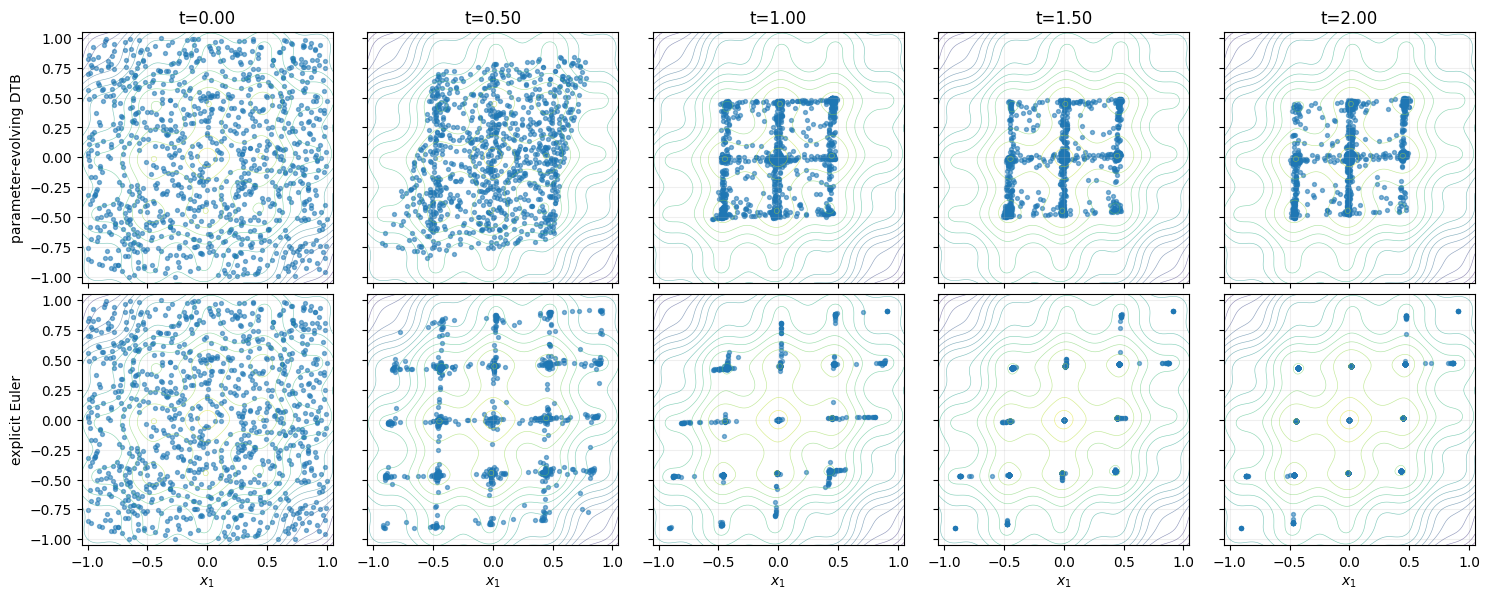

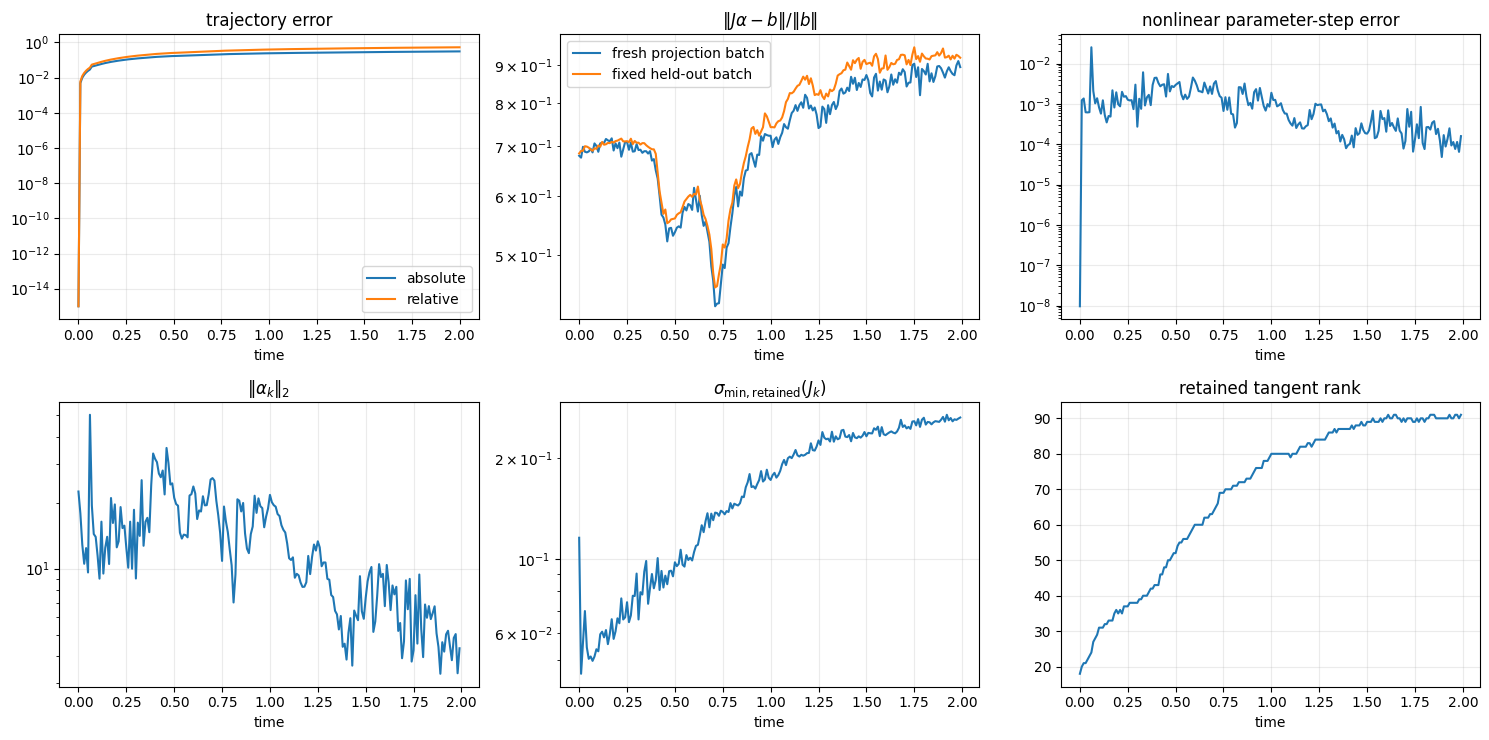

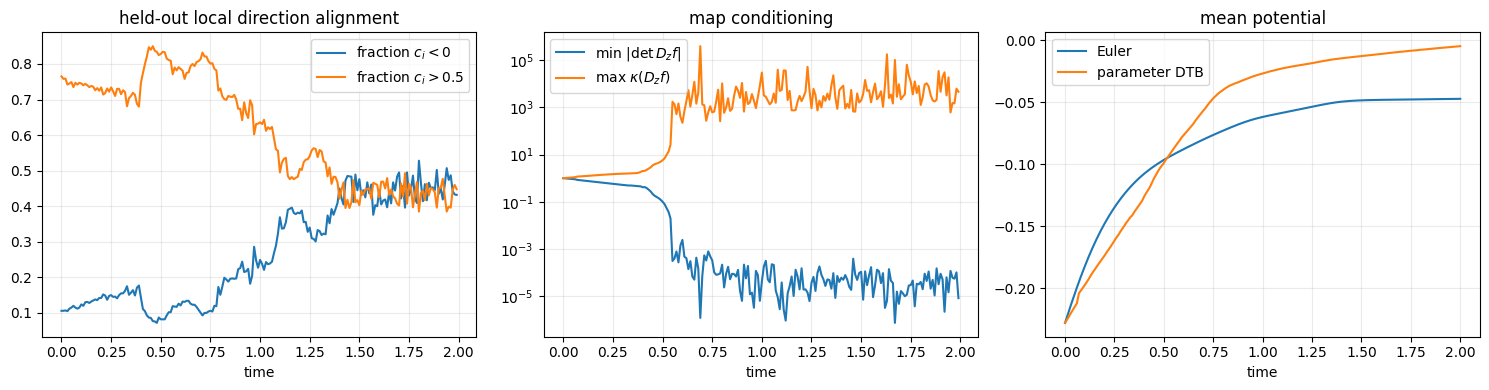

In [18]:
# BLOCK 5 — Phase portraits and the smallest set of failure diagnostics.
grid_axis = torch.linspace(-1.05, 1.05, 140)
grid_x1, grid_x2 = torch.meshgrid(grid_axis, grid_axis, indexing="xy")
potential_grid = phi(torch.stack((grid_x1.ravel(), grid_x2.ravel()), -1)).reshape(grid_x1.shape)
fig, axes = plt.subplots(2, len(SNAPSHOT_STEPS), figsize=(3 * len(SNAPSHOT_STEPS), 6),
                         sharex=True, sharey=True)
for column, step in enumerate(SNAPSHOT_STEPS):
    for row in range(2):
        axes[row, column].contour(grid_x1, grid_x2, potential_grid, levels=16,
                                  linewidths=.45, alpha=.55)
    dtb_points = result["trajectory"][step].numpy()
    ref_points = reference_trajectory[step].numpy()
    axes[0, column].scatter(dtb_points[:, 0], dtb_points[:, 1], s=8, alpha=.55)
    axes[1, column].scatter(ref_points[:, 0], ref_points[:, 1], s=8, alpha=.55)
    axes[0, column].set_title(f"t={step * H:.2f}")
    for row in range(2):
        axes[row, column].grid(alpha=.2); axes[row, column].set_aspect("equal")
axes[0, 0].set_ylabel("parameter-evolving DTB")
axes[1, 0].set_ylabel("explicit Euler")
for axis in axes[1]: axis.set_xlabel(r"$x_1$")
plt.tight_layout(); plt.show()

state_times = np.arange(K + 1) * H
step_times = np.arange(K) * H
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
axes[0, 0].semilogy(state_times, trajectory_rmse + 1e-15, label="absolute")
axes[0, 0].semilogy(state_times, relative_rmse + 1e-15, label="relative")
axes[0, 0].set_title("trajectory error"); axes[0, 0].legend()
axes[0, 1].semilogy(step_times, result["projection_residual"] + 1e-15,
                     label="fresh projection batch")
axes[0, 1].semilogy(step_times, result["evaluation_residual"] + 1e-15,
                     label="fixed held-out batch")
axes[0, 1].set_title(r"$\|J\alpha-b\|/\|b\|$"); axes[0, 1].legend()
axes[0, 2].semilogy(step_times, result["map_step_error"] + 1e-15)
axes[0, 2].set_title("nonlinear parameter-step error")
axes[1, 0].semilogy(step_times, result["alpha_norm"] + 1e-15)
axes[1, 0].set_title(r"$\|\alpha_k\|_2$")
axes[1, 1].semilogy(step_times, result["sigma_min_retained"] + 1e-15)
axes[1, 1].set_title(r"$\sigma_{\min,\mathrm{retained}}(J_k)$")
axes[1, 2].plot(step_times, result["retained_rank"])
axes[1, 2].set_title("retained tangent rank")
for axis in axes.ravel():
    axis.set_xlabel("time"); axis.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(step_times, result["fraction_negative"], label=r"fraction $c_i<0$")
axes[0].plot(step_times, result["fraction_above_half"], label=r"fraction $c_i>0.5$")
axes[0].set_title("held-out local direction alignment"); axes[0].legend()
axes[1].semilogy(step_times, result["min_abs_map_det"] + 1e-15, label=r"min $|\det D_zf|$")
axes[1].semilogy(step_times, result["max_map_condition"] + 1e-15, label=r"max $\kappa(D_zf)$")
axes[1].set_title("map conditioning"); axes[1].legend()
axes[2].plot(state_times, potential_reference, label="Euler")
axes[2].plot(state_times, potential_dtb, label="parameter DTB")
axes[2].set_title("mean potential"); axes[2].legend()
for axis in axes:
    axis.set_xlabel("time"); axis.grid(alpha=.25)
plt.tight_layout(); plt.show()

## Reading this resampling trial

- `projection_residual` is computed on the fresh batch that determines \(\alpha_k\); `evaluation_residual` is computed on the same fixed held-out labels at every step. Their gap measures sampling/generalization error.
- `map_step_error` isolates the difference between the linear tangent prediction and the actual nonlinear parameter update.
- A small retained singular value can amplify \(\alpha_k\); compare both plots rather than interpreting either alone.
- The direction fractions, determinant, condition number, trajectory error, and map-step error all use fixed evaluation labels; resampled fitting particles never replace this evaluation set.
- The explicit-Euler reference uses the same \(h\), so its discrepancy primarily reflects tangent projection and nonlinear parameter-update error, not a mismatch of time integrators.